#  Evolutionary Multiple-objective Optimization (part for 4.0)

- This script is for those who want to improve their final grade from 3.0 to 4.0. 
- Your task is to implement any one evolutionary algorithm for multiple-objective optimization introduced during the lecture (NSGA-II/NSGA-III/MOEA/D; except for NSGA).
- Note that it has to be your implementation (using external libraries is forbidden; EXCEPTION: you can use the JECDM framework: https://jecdm.cs.put.poznan.pl -- but it is a relatively complex software, and much effort must be spent to understand how to use it).
- The problem to be solved is the portfolio optimization tackled during lab 1.
- You can use the same data and price predictions as you made for lab 1 (Bundle1.zip) or update them accordingly to the next stage if you participate in the portfolio game (it is up to you).
- Apart from the two-objective scenario, tackle also a three-objective one. As for the third objective, think about some reasonable risk-measure. E.g., you can maximize the number of non-zero weights, which should refer to minimizing risk by diversifying investments.
- Perform experimental evaluation of your implementation. You can use, e.g., the IDG or the HV metric to quantify the quality of populations constructed by the method.
- The experimental evaluation should be "reasonably extensive." E.g., run your method multiple times and average the results, show average convergence plots, do the sensitivity analysis (just four combinations of population size/generations will be enough), and depict some final populations. Also, compare the populations (only for 2D scenarios) with those generated by the ECM or WSM algorithm. Note that ECM and WSM already generate Pareto optimal solutions, so these can be considered good benchmarks for comparison.
- You can report your results here, i.e., in the jupyter notebook. You do not need to prepare any pdf report, etc. 

In [1]:
from utils.MOO_utilities import *

In [2]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

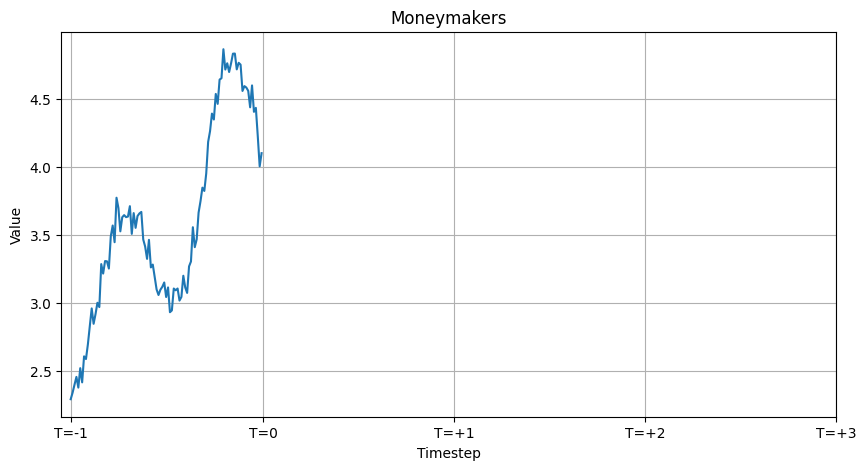

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

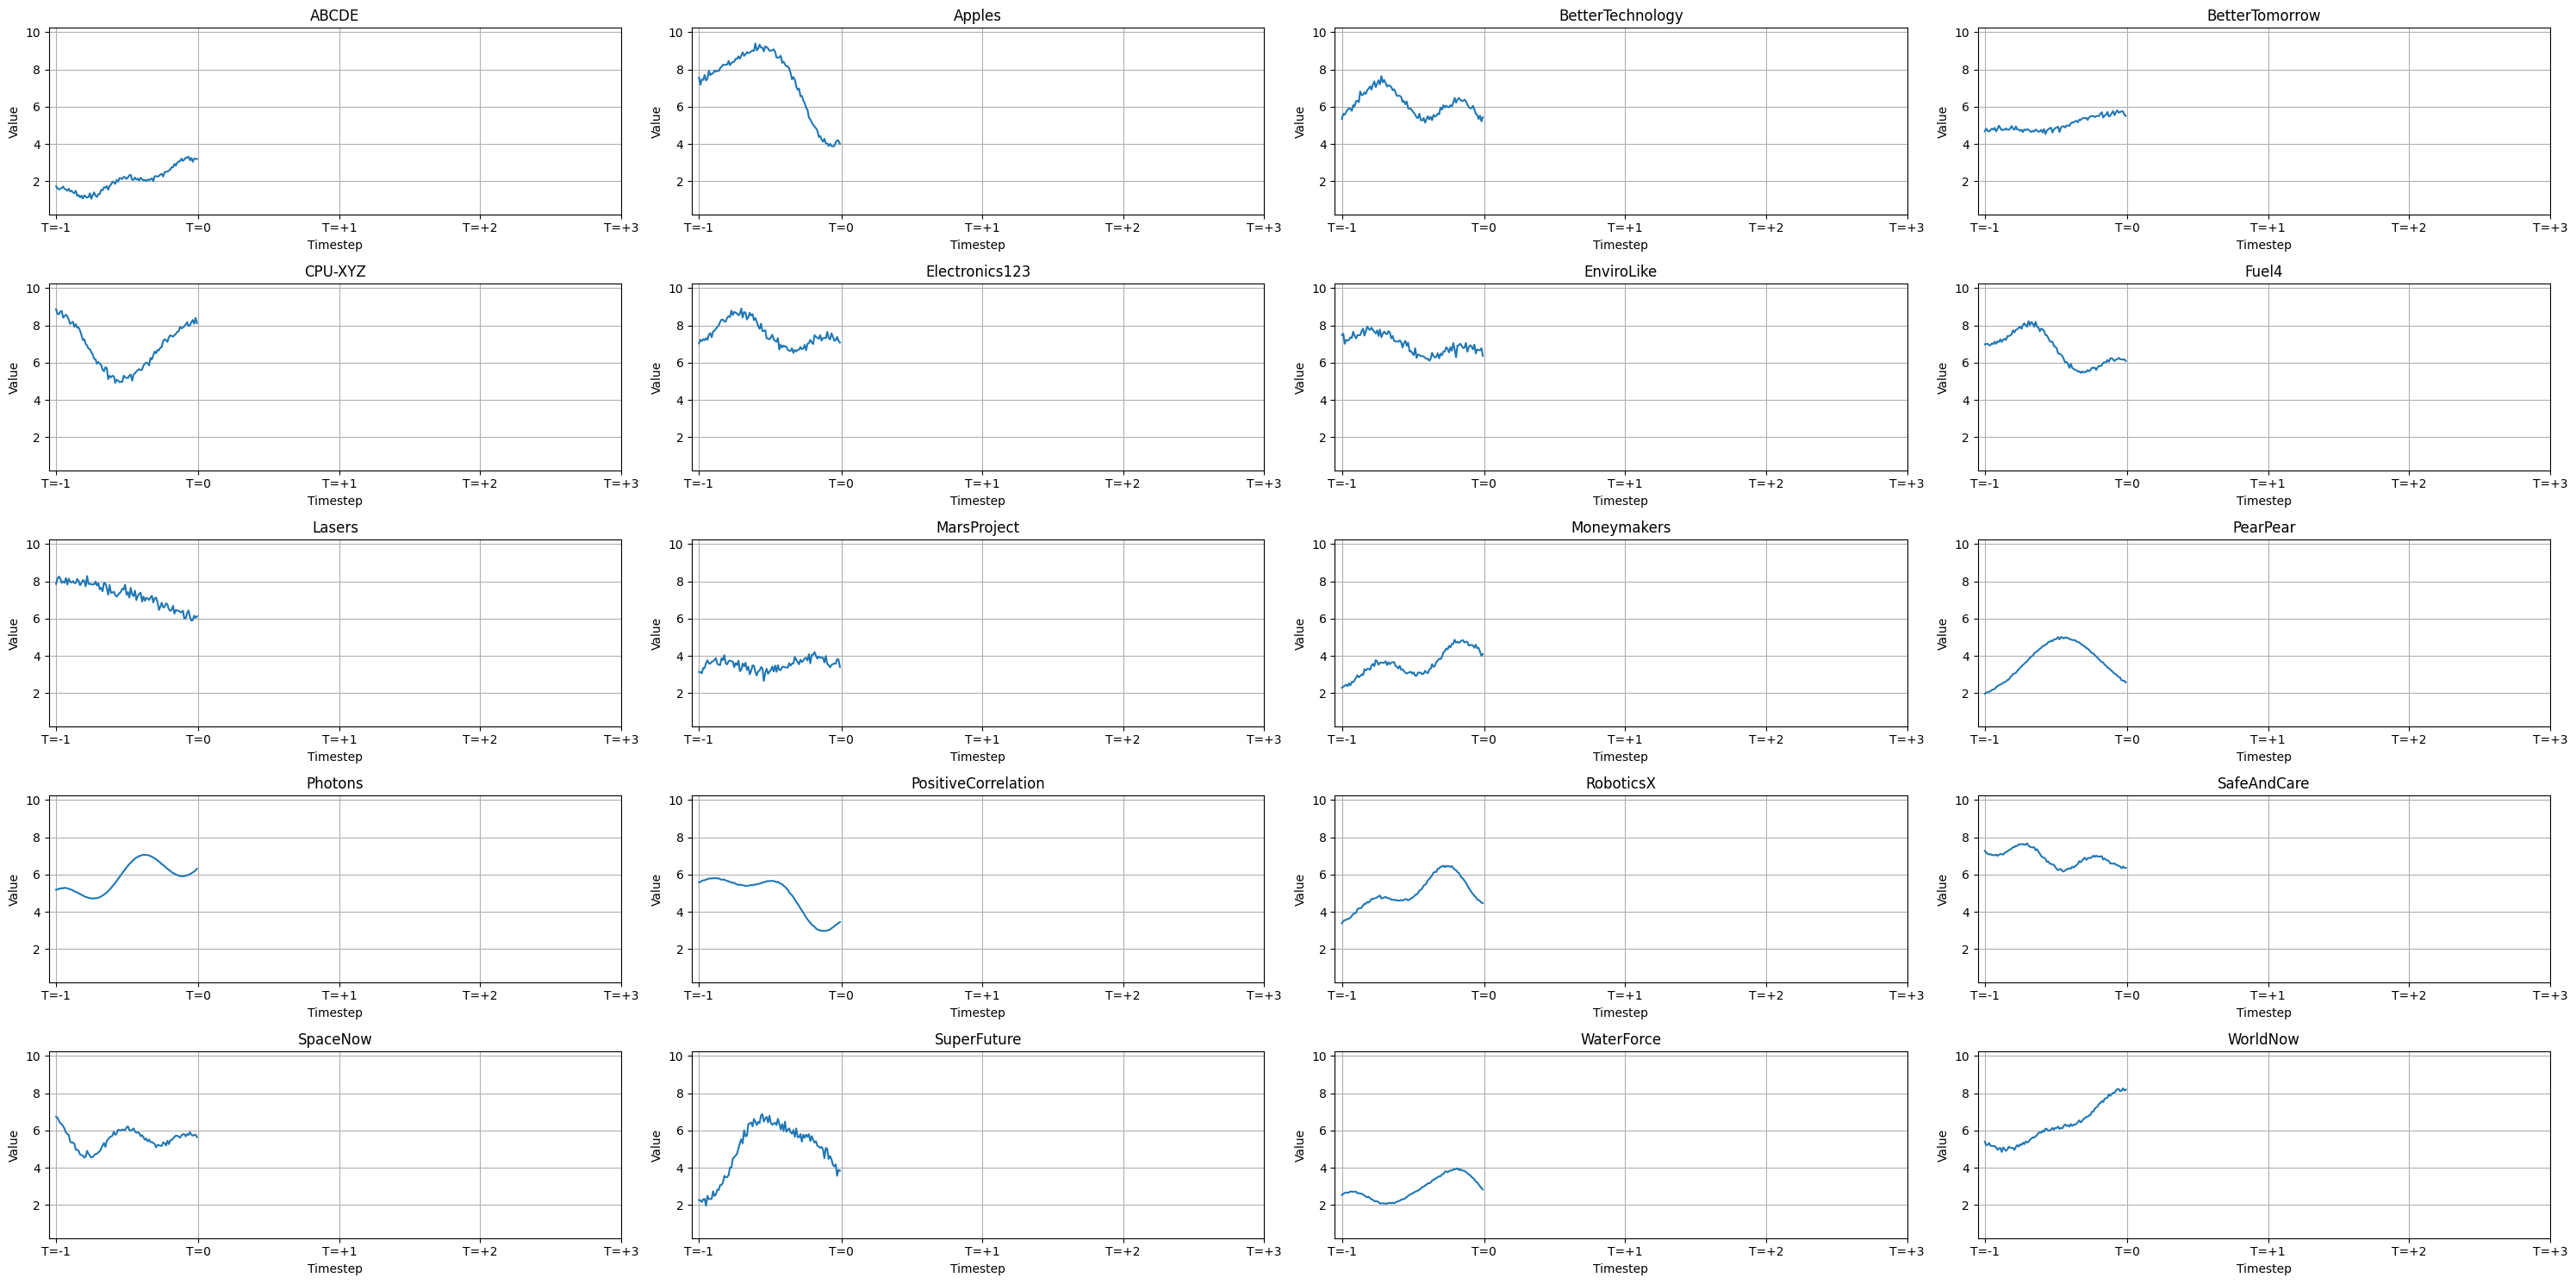

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

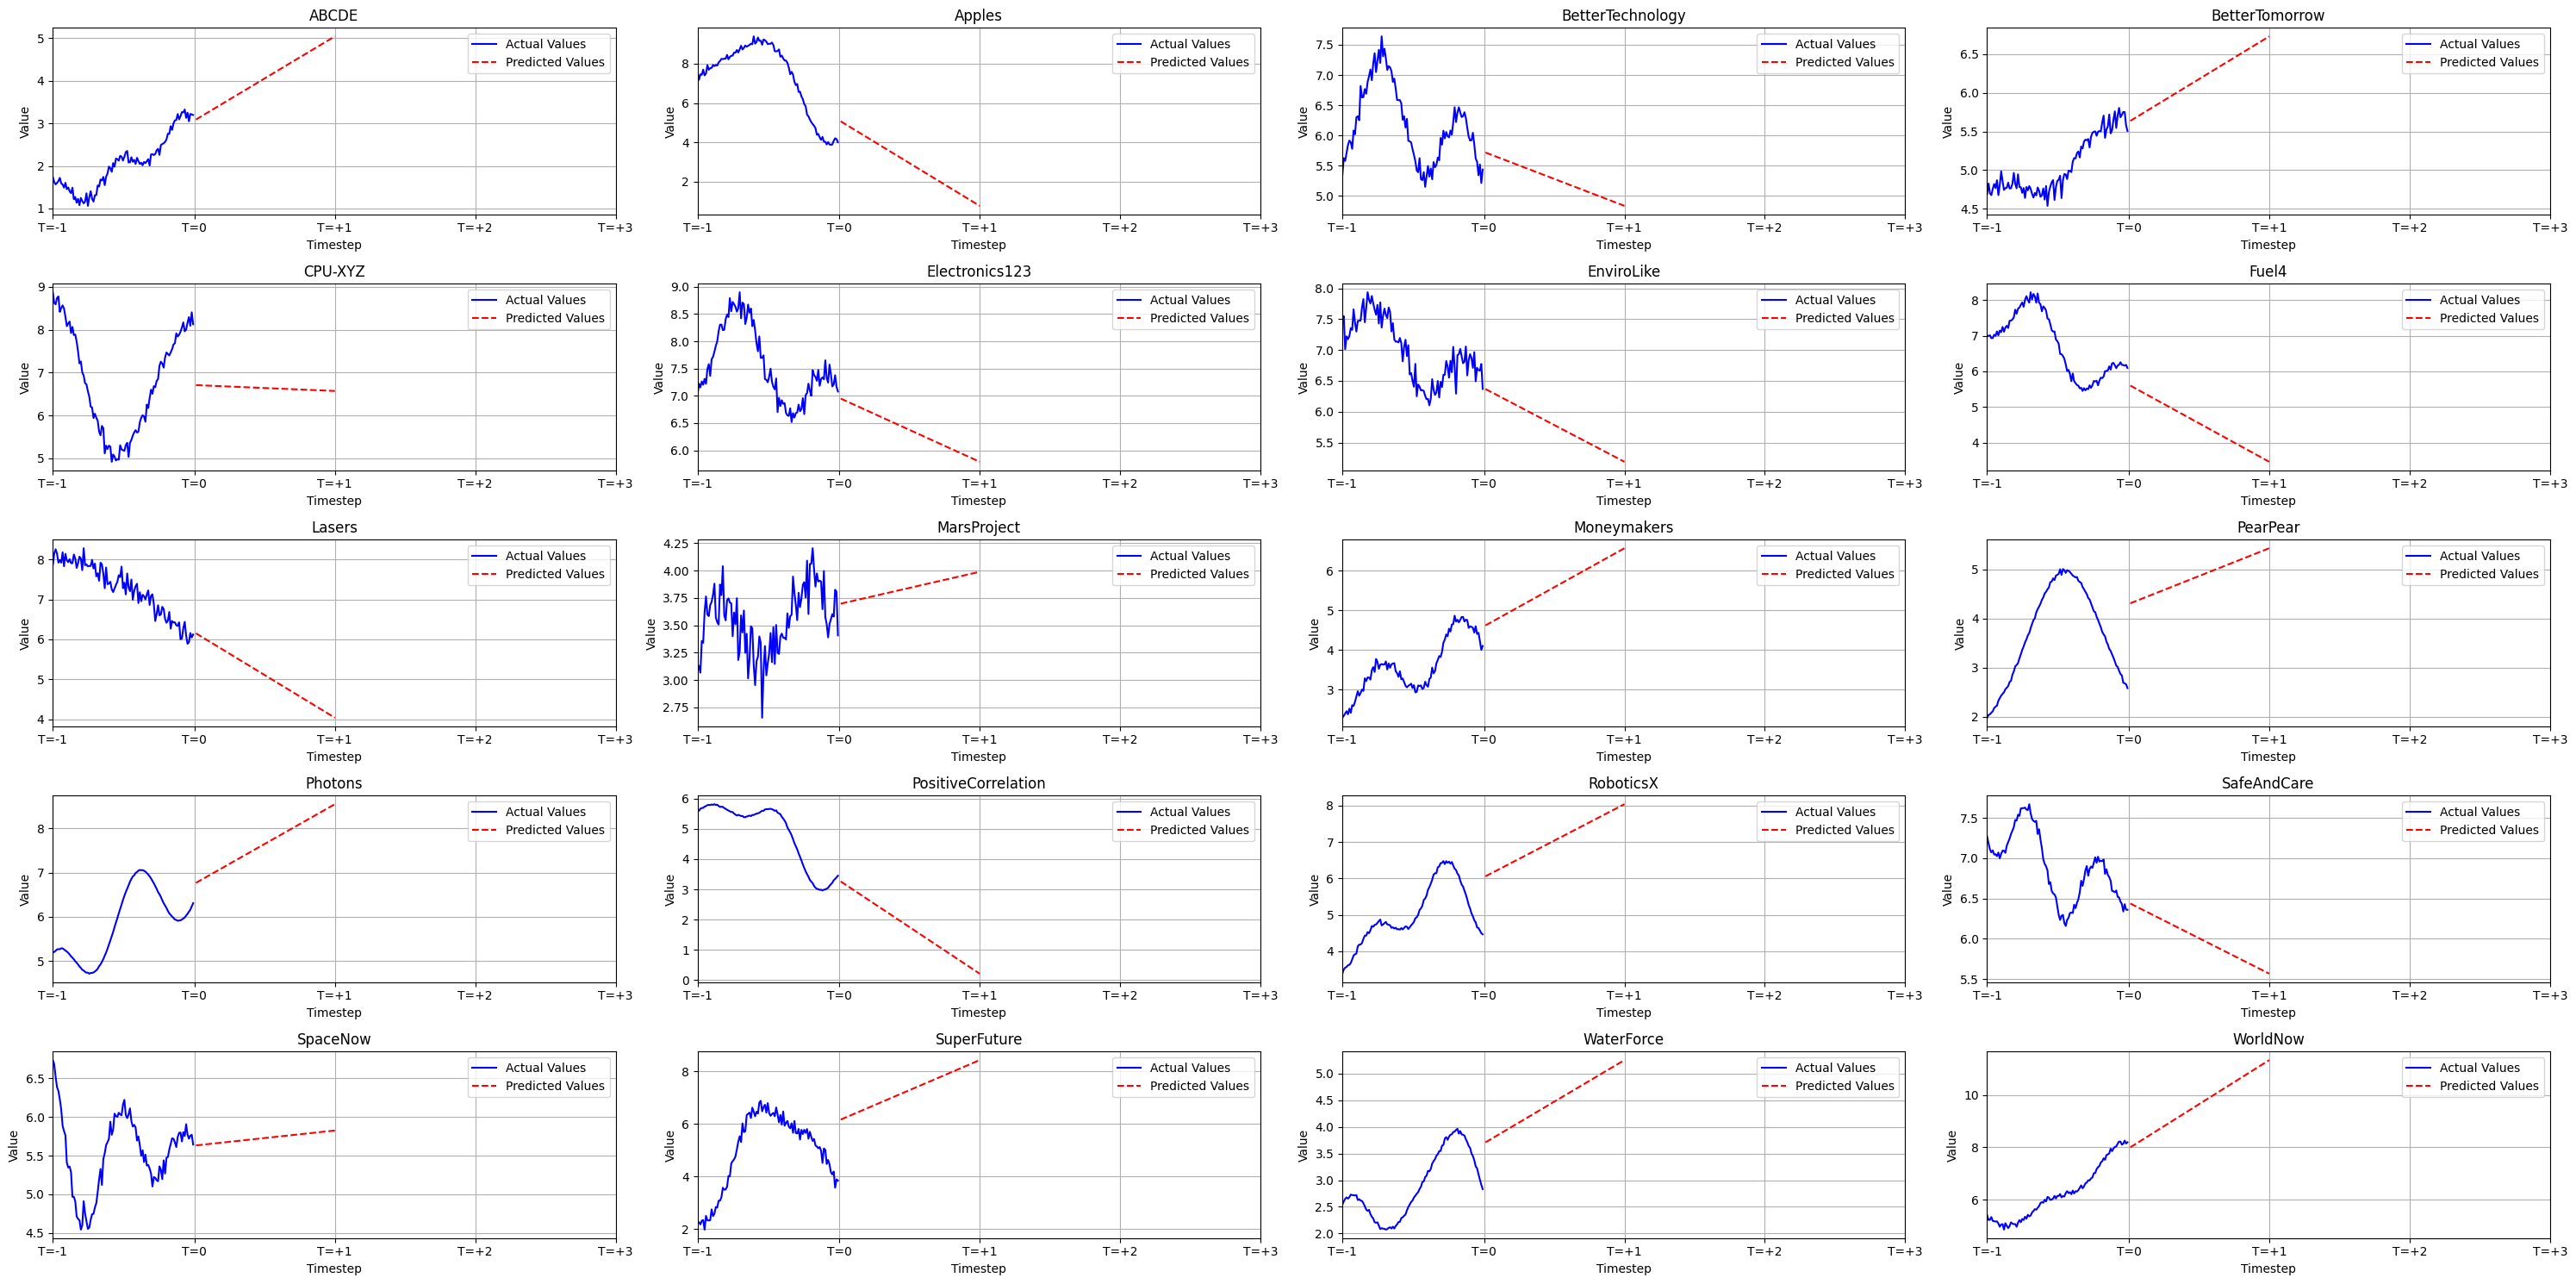

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

In [6]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, linear_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [7]:
class GeneticSolver(Solver):
    def __init__(self, data, predicted_vals, risks, population_size, mutation_probability, weight_size=20, num_dimensions=2):
        super().__init__(data, predicted_vals, risks)
        self.population_size = population_size  
        self.weight_size = weight_size
        self.log_history = False
        self.num_dimensions = num_dimensions
        self.mutation_prob = mutation_probability

    def enable_loging(self):
        self.log_history = True
    
    def disable_loging(self):
        self.log_history = False

    def normalize(self, population):
        return population / population.sum(axis=1, keepdims=True)

    def generate_population(self):
        population = np.array([[random.random() for i in range(self.weight_size)].copy() for i in range(self.population_size)], dtype=np.float32)
        population = self.normalize(population)
        if self.log_history:
            self.population_history = []
            self.population_history.append(population.copy()) 
        return population
    
    def initialize_chebyshev(self):
        if self.num_dimensions <= 1:
            print("At least two dimensions must be present")
            raise ValueError
        elif self.num_dimensions == 2:
            samples_dim_1 = np.linspace(0, 1, self.population_size)
            samples_dim_2 = 1 - samples_dim_1
            weights = []
            for i in range(len(samples_dim_1)):
                weights.append([samples_dim_1[i], samples_dim_2[i]])
            weights = np.array(weights, dtype=np.float32)
        else:
            weights = np.random.dirichlet(np.ones(self.num_dimensions), self.population_size).astype(np.float32)
        return weights
    
    def crossover(self, chebyshev_weights, neighborhoods, weight_to_individual_map):
        offsprings = []
        for weight in chebyshev_weights:
            neighboring_weights = neighborhoods[tuple(weight)].copy()
            random.shuffle(neighboring_weights)
            weight_parent_1, weight_parent_2 = neighboring_weights[:2]
            parent_1, parent_2 = weight_to_individual_map[weight_parent_1], weight_to_individual_map[weight_parent_2]
            crossing_point = random.randint(0, len(parent_1)-1)
            result = np.concatenate((parent_1[:crossing_point], parent_2[crossing_point:]))
            offsprings.append(result)
        offsprings = np.array(offsprings, dtype=np.float32)
        return offsprings
    
    def mutate(self, population):
        new_population = []
        for individual in population:
            if random.random() < self.mutation_prob:
                idx = random.randint(0, len(individual) - 1)
                individual[idx] = random.random()
            new_population.append(individual)
        new_population = np.array(new_population, dtype=np.float32)
        return new_population
    
    def find_neighborhoods(self, chebyshev_weights, neighborhood_size):
        distances = np.abs(chebyshev_weights[:, None] - chebyshev_weights).sum(axis=-1)
        neighbors_dict = {}
        for i, w in enumerate(chebyshev_weights):
            sorted_indices = np.argsort(distances[i])
            closest_indices = sorted_indices[1:neighborhood_size+1]
            neighbors_dict[tuple(w)] = [tuple(chebyshev_weights[j]) for j in closest_indices]
        return neighbors_dict
    
    def assign_chebyshev_weights(self, population, chebyshev_weights):
        np.random.shuffle(chebyshev_weights)
        weight_to_individual_map = {tuple(chebyshev_weights[i]): population[i] for i in range(self.population_size)}
        return weight_to_individual_map
    
    def calculate_chebyshev_distance(self, weight, investment_vector):
        #TODO: Review
        potential_gain = self.maxf1 - (investment_vector.T @ self.expected_returns)
        #risk = np.sqrt(investment_vector.T @ self.risks @ investment_vector)
        risk = investment_vector.T @ self.risks @ investment_vector
        potential_gain = (potential_gain - self.minf1)/(self.maxf1 - self.minf1)
        risk = (risk - self.minf2)/(self.maxf2 - self.minf2)
        return max(weight[0]*potential_gain, weight[1]*risk)
    
    def calculate_chebyshev_3d_distance(self, weight, investment_vector):
        #TODO: Review
        potential_gain = self.maxf1 - (investment_vector.T @ self.expected_returns)
        #risk = np.sqrt(investment_vector.T @ self.risks @ investment_vector)
        risk = investment_vector.T @ self.risks @ investment_vector
        potential_gain = (potential_gain - self.minf1)/(self.maxf1 - self.minf1)
        num_zero_weights = np.sum(investment_vector < 0.01)/self.weight_size
        risk = (risk - self.minf2)/(self.maxf2 - self.minf2)
        return max(weight[0]*potential_gain, weight[1]*risk, weight[2] * num_zero_weights)
    
    def perform_selection(self, population, offsprings, chebyshev_weights, weight_to_individual_map):
        #Spaghetti code, but I do not care as long as it works
        complete_pool = np.concatenate((population, offsprings))
        next_generation = []
        for weight in chebyshev_weights:
            current_best = None
            if self.num_dimensions == 3:
                chebyshev_distance_current = self.calculate_chebyshev_3d_distance(weight, weight_to_individual_map[tuple(weight)])
            else:
                chebyshev_distance_current = self.calculate_chebyshev_distance(weight, weight_to_individual_map[tuple(weight)])
            for individual in complete_pool:
                if self.num_dimensions == 3:
                    chebyshev_distance_new = self.calculate_chebyshev_3d_distance(weight, individual)
                else:
                    chebyshev_distance_new = self.calculate_chebyshev_distance(weight, individual)
                if chebyshev_distance_new <= chebyshev_distance_current:
                    current_best = individual
            next_generation.append(current_best)
            weight_to_individual_map[tuple(weight)] = current_best
        return np.array(next_generation, dtype=np.float32), weight_to_individual_map

    def genetic_optimize(self, generations=10, neighborhood_size=2):
        chebyshev_weights = self.initialize_chebyshev()
        neighborhoods = self.find_neighborhoods(chebyshev_weights, neighborhood_size)
        population = self.generate_population()
        population = self.normalize(population)
        weight_to_individual_map = self.assign_chebyshev_weights(population, chebyshev_weights)
        for generation in range(generations):
            offsprings = self.crossover(chebyshev_weights, neighborhoods, weight_to_individual_map)
            offsprings = self.normalize(offsprings)
            offsprings = self.mutate(offsprings)
            offsprings = self.normalize(offsprings)
            population, weight_to_individual_map = self.perform_selection(population, offsprings, chebyshev_weights, weight_to_individual_map)
            if self.log_history:
                self.population_history.append(population.copy())
        return population
    
    def get_solutions_from_population(self, population):
        #TODO: Review the risk formula, please ;)
        solutions = []
        for individual in population:
            solution = []
            potential_gain = individual.T @ self.expected_returns
            #risk = np.sqrt(individual.T @ self.risks @ individual)
            risk = individual.T @ self.risks @ individual
            solution.append(potential_gain)
            solution.append(risk)
            solution.append(individual.copy())
            solutions.append(solution.copy())
        return solutions
    
    def get_solutions_from_population_3D(self, population):
        #TODO: Review the risk formula, please ;)
        solutions = []
        for individual in population:
            solution = []
            potential_gain = individual.T @ self.expected_returns
            #risk = np.sqrt(individual.T @ self.risks @ individual)
            risk = individual.T @ self.risks @ individual
            num_zero_weights = np.sum(individual < 0.01)/self.weight_size
            solution.append(potential_gain)
            solution.append(risk)
            solution.append(num_zero_weights)
            solution.append(individual.copy())
            solutions.append(solution.copy())
        return solutions

    def plot_sampled_3D(self, n=20, step=0.2, color=True):
        random_points = []        
        results = self._generate_uniform_weights(n, step)
        
        for res in results:  
            sol_weights = np.array(res)
            f1, f2 = self.get_objective_values(sol_weights)  # Assuming f3 exists
            f3 = np.sum(sol_weights < 0.01)/self.weight_size
            random_points.append((f1, f2, f3))
        
        if color:
            plt.figure(figsize=(10, 9))
            scatter = plt.scatter(
                [x[0] for x in random_points], 
                [x[1] for x in random_points], 
                c=[x[2] for x in random_points],  # Color by f3
                cmap='viridis', 
                edgecolors='k'
            )
            plt.colorbar(scatter, label='Non-Zero Weights')
            plt.xlabel("Expected Return")
            plt.ylabel("Risk")
            plt.title("Sampled Decision Variables")
            plt.grid(True)
            plt.show()
        else:
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            
            axs[0].scatter([x[0] for x in random_points], [x[1] for x in random_points])
            axs[0].set_xlabel("Expected Gain")
            axs[0].set_ylabel("Risk")
            axs[0].set_title("Expected Gain vs Risk")
            
            axs[1].scatter([x[1] for x in random_points], [x[2] for x in random_points])
            axs[1].set_xlabel("Risk")
            axs[1].set_ylabel("Non-Zero Weights")
            axs[1].set_title("Risk vs Non-Zero Weights")
            
            axs[2].scatter([x[0] for x in random_points], [x[2] for x in random_points])
            axs[2].set_xlabel("Expected Gain")
            axs[2].set_ylabel("Non-Zero Weights")
            axs[2].set_title("Expected Gain vs Non-Zero Weights")
            
            for ax in axs:
                ax.grid(True)
            
            plt.tight_layout()
            plt.show()

    def plot_front_3D(self, solutions, n=20, step=0.2, color=True):
        random_points = []        
        results = self._generate_uniform_weights(n, step)
        
        for res in results:  
            sol_weights = np.array(res)
            f1, f2 = self.get_objective_values(sol_weights)  # Assuming f3 exists
            f3 = np.sum(sol_weights < 0.01)/self.weight_size
            random_points.append((f1, f2, f3))
        
        if color:
            plt.figure(figsize=(10, 9))
            scatter = plt.scatter(
                [x[0] for x in random_points], 
                [x[1] for x in random_points], 
                c=[x[2] for x in random_points],  # Color by f3
                cmap='viridis', 
                edgecolors='k',
                alpha=0.3
            )
            plt.colorbar(scatter, label='Non-Zero Weights')
            
            solution_colors = [x[2] for x in solutions]  # Color solutions by their f3 values
            sol_scatter = plt.scatter(
                [x[0] for x in solutions], 
                [x[1] for x in solutions], 
                c=solution_colors, 
                cmap='coolwarm',  # Different gradient
                edgecolors='black',
                linewidths=1.5,
                label='Front Solutions'
            )
            plt.colorbar(sol_scatter, label='Solution Non-Zero Weights')
            
            plt.xlabel("Expected Return")
            plt.ylabel("Risk")
            plt.title("Sampled Decision Variables")
            plt.legend()
            plt.grid(True)
            plt.show()
        else:
            fig, axs = plt.subplots(1, 3, figsize=(15, 5))
            
            axs[0].scatter([x[0] for x in random_points], [x[1] for x in random_points], alpha=0.8)
            axs[0].scatter([x[0] for x in solutions], [x[1] for x in solutions], color="red", linewidths=2)
            axs[0].set_xlabel("Expected Gain")
            axs[0].set_ylabel("Risk")
            axs[0].set_title("Expected Gain vs Risk")
            
            axs[1].scatter([x[1] for x in random_points], [x[2] for x in random_points], alpha=0.8)
            axs[1].scatter([x[1] for x in solutions], [x[2] for x in solutions], color="red", linewidths=2)
            axs[1].set_xlabel("Risk")
            axs[1].set_ylabel("Non-Zero Weights")
            axs[1].set_title("Risk vs Non-Zero Weights")
            
            axs[2].scatter([x[0] for x in random_points], [x[2] for x in random_points], alpha=0.8)
            axs[2].scatter([x[0] for x in solutions], [x[2] for x in solutions], color="red", linewidths=2)
            axs[2].set_xlabel("Expected Gain")
            axs[2].set_ylabel("Non-Zero Weights")
            axs[2].set_title("Expected Gain vs Non-Zero Weights")
            
            for ax in axs:
                ax.grid(True)
            
            plt.tight_layout()
            plt.show()

    
GS = GeneticSolver(data, linear_predictions, risks, population_size=100, mutation_probability=0.8, weight_size=20, num_dimensions=2)
population = GS.genetic_optimize(generations=100, neighborhood_size=5)
solutions = GS.get_solutions_from_population(population)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


In [8]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,0.999095,0.407439,0.000080,0.000002,0.000534,0.000077,0.001622,0.000007,0.597151,0.001023,...,0.004739,0.000103,0.000174,0.000057,0.004762,0.000332,0.387421,0.000110,0.000072,1.0
1,1.164711,1.599592,0.726308,0.000002,0.000135,0.000010,0.000214,0.000001,0.252229,0.000027,...,0.001609,0.000017,0.000023,0.000008,0.000643,0.000019,0.018155,0.000012,0.000008,1.0
2,1.164711,1.599592,0.726308,0.000002,0.000135,0.000010,0.000214,0.000001,0.252229,0.000027,...,0.001609,0.000017,0.000023,0.000008,0.000643,0.000019,0.018155,0.000012,0.000008,1.0
3,1.065966,0.678454,0.000117,0.000004,0.000464,0.000058,0.001057,0.000005,0.859171,0.000140,...,0.007772,0.000140,0.000099,0.000041,0.003436,0.000109,0.122712,0.000040,0.000118,1.0
4,0.978022,0.347333,0.000080,0.000002,0.000178,0.000027,0.000495,0.000002,0.503631,0.000676,...,0.004162,0.000066,0.000057,0.000024,0.001975,0.000053,0.487601,0.000015,0.000015,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.905791,0.271334,0.000111,0.000002,0.000290,0.000060,0.001268,0.000006,0.311885,0.002897,...,0.014732,0.000265,0.000161,0.000038,0.003179,0.012510,0.647611,0.000036,0.000023,1.0
96,0.872018,0.238742,0.000119,0.000006,0.000528,0.000066,0.001388,0.000021,0.400345,0.000104,...,0.011399,0.000205,0.000177,0.062230,0.006133,0.000163,0.497972,0.010615,0.000087,1.0
97,0.792623,0.173830,0.000106,0.000005,0.000501,0.000153,0.003216,0.000014,0.303576,0.000079,...,0.012738,0.068023,0.000179,0.000058,0.002831,0.000083,0.560880,0.000032,0.000021,1.0
98,0.974268,0.339622,0.000078,0.000001,0.000173,0.000026,0.000480,0.000002,0.488421,0.000656,...,0.004037,0.000064,0.000056,0.000023,0.001933,0.000051,0.503051,0.000017,0.000017,1.0


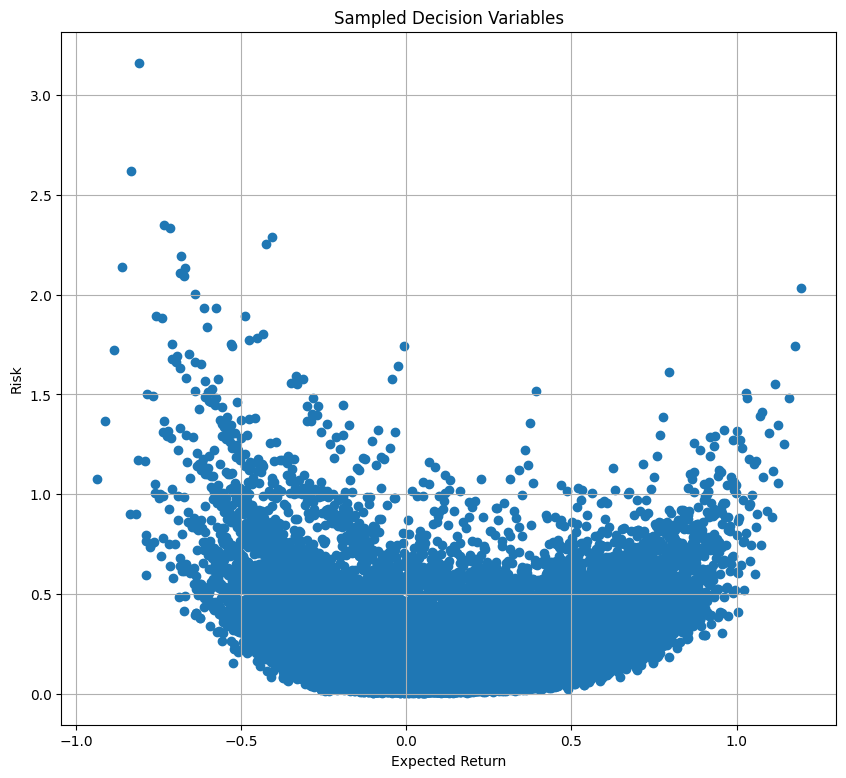

In [9]:
solver.plot_sampled_decision_variables(20, 0.2)

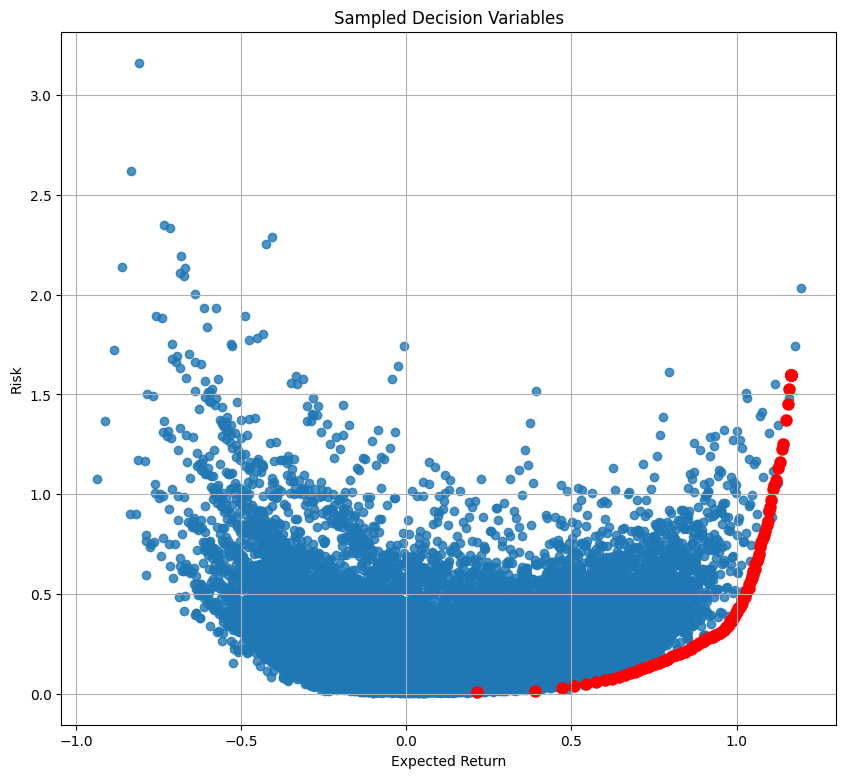

In [10]:
solver.plot_front(solutions, n=20, step=0.2)

In [11]:
GS = GeneticSolver(data, linear_predictions, risks, population_size=100, mutation_probability=0.8, weight_size=20, num_dimensions=3)
population = GS.genetic_optimize(generations=100, neighborhood_size=5)
solutions = GS.get_solutions_from_population_3D(population)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.4443e+00 -3.1919e+01  1e+02  2e+00  3e-16
 1: -1.0566e+00 -1.4202e+01  2e+01  8e-02  7e-16
 2: -7.4377e-01 -1.4687e+00  7e-01  1e-03  9e-16
 3: -1.1367e+00 -1.3535e+00  2e-01  1e-04  5e-16
 4: -1.1890e+00 -1.2006e+00  1e-02  6e-06  4e-16
 5: -1.1953e+00 -1.1954e+00  1e-04  6e-08  4e-16
 6: -1.1954e+00 -1.1954e+00  1e-06  6e-10  5e-16
 7: -1.1954e+00 -1.1954e+00  1e-08  6e-12  5e-16
Optimal solution found.


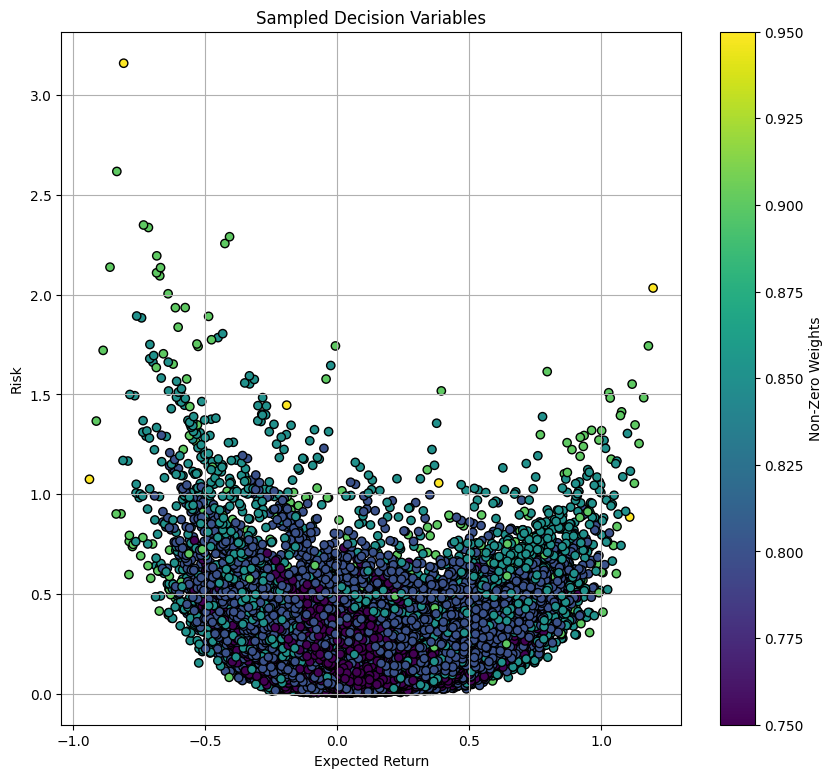

In [12]:
GS.plot_sampled_3D()

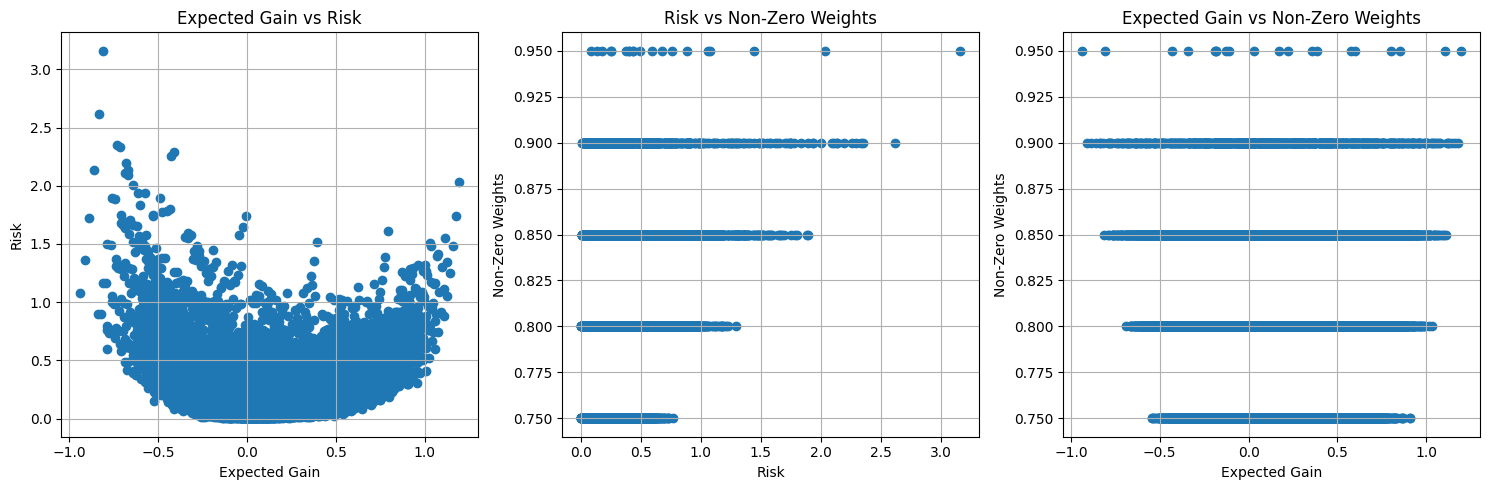

In [13]:
GS.plot_sampled_3D(color=False)

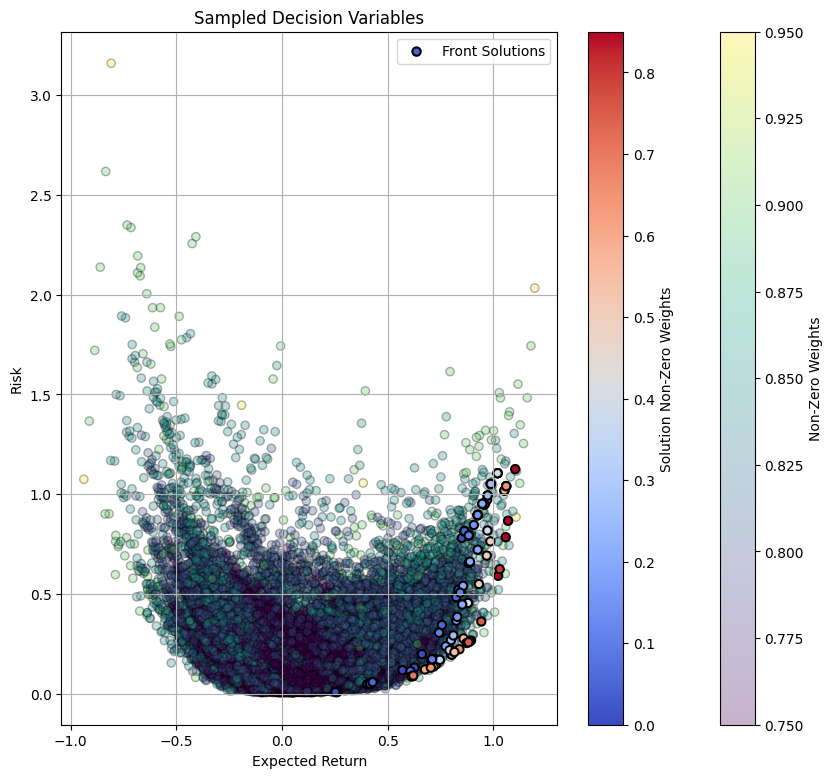

In [14]:
GS.plot_front_3D(solutions)

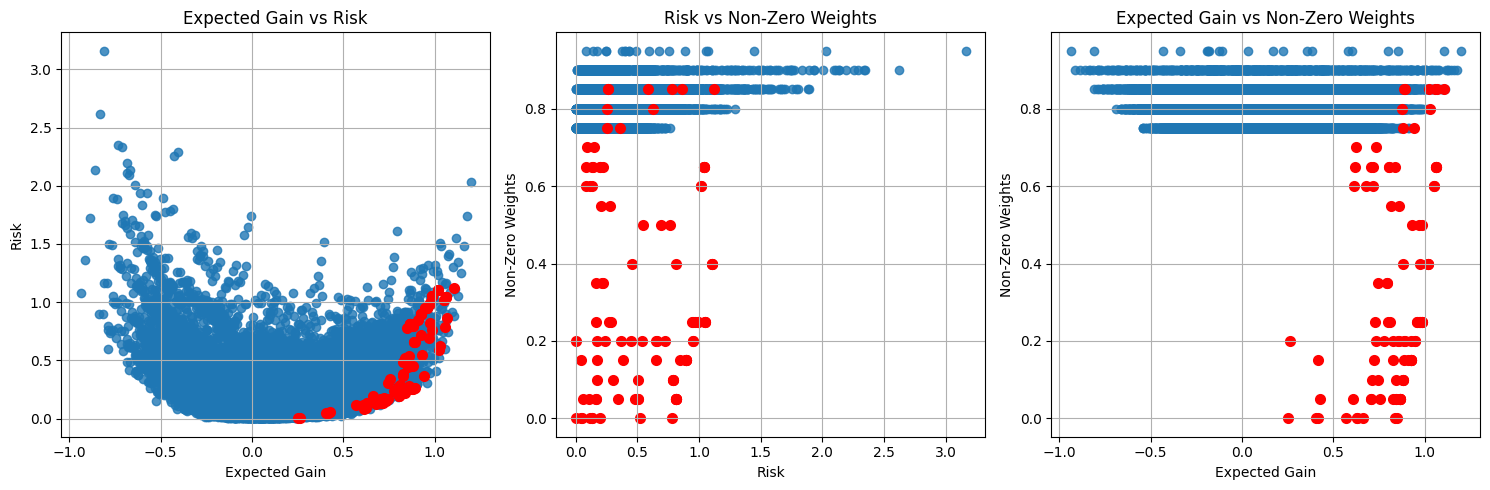

In [15]:
GS.plot_front_3D(solutions, color=False)